# Sample

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Task 1 - Load and View Data

In [ ]:
data_path = "diabetes.csv"
target_col = "has_diabetes"
feature_cols = ["chol", "stab.glu", "hdl", "age"]
zero_invalid_cols = []

df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]

# Create binary target if needed (glyhb >= 7.0 -> diabetic)
if target_col not in df.columns and "glyhb" in df.columns:
    glyhb_num = pd.to_numeric(df["glyhb"], errors="coerce")
    df[target_col] = np.where(glyhb_num.notna(), (glyhb_num >= 7.0).astype(int), np.nan)

print("Shape:", df.shape)
display(df.head())

# Lab-style quick structure check
print("\nDataFrame info:")
df.info()

print("\nDtypes:")
display(df.dtypes)
print("\nClass counts:")
print(df[target_col].value_counts(dropna=False))

# Lab-style quality checks
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (403, 20)


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn,has_diabetes
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0,0.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0,0.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0,0.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0,0.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0,1.0



Dtypes:


id                int64
chol            float64
stab.glu          int64
hdl             float64
ratio           float64
glyhb           float64
location            str
age               int64
gender              str
height          float64
weight          float64
frame               str
bp.1s           float64
bp.1d           float64
bp.2s           float64
bp.2d           float64
waist           float64
hip             float64
time.ppn        float64
has_diabetes    float64
dtype: object


Class counts:
has_diabetes
0.0    330
1.0     60
NaN     13
Name: count, dtype: int64


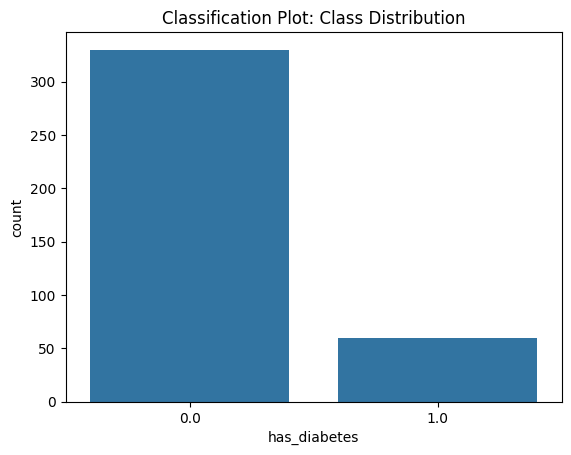

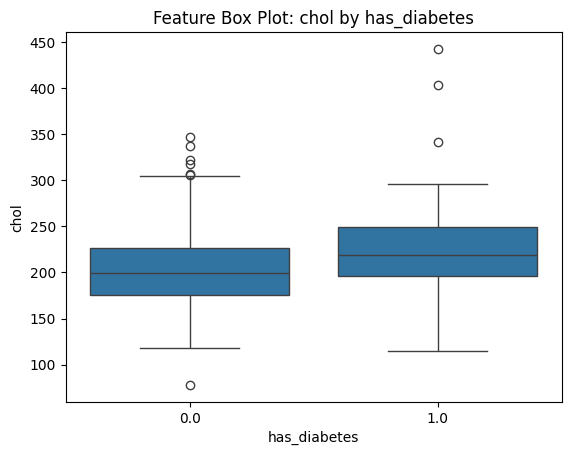

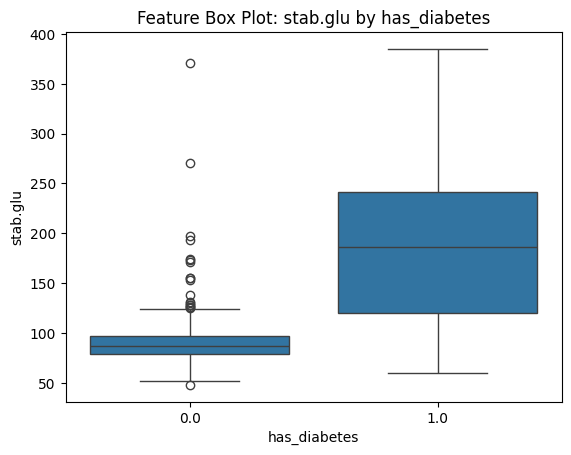

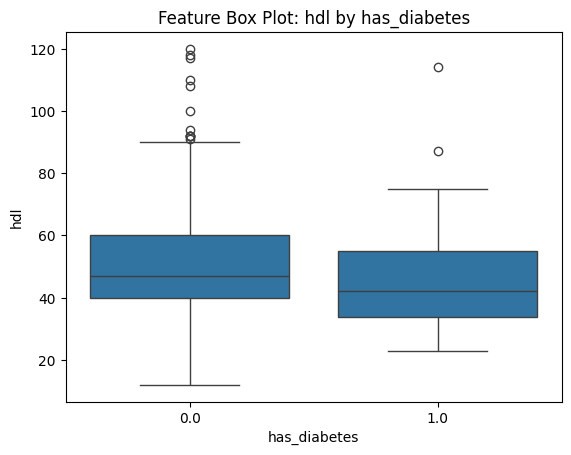

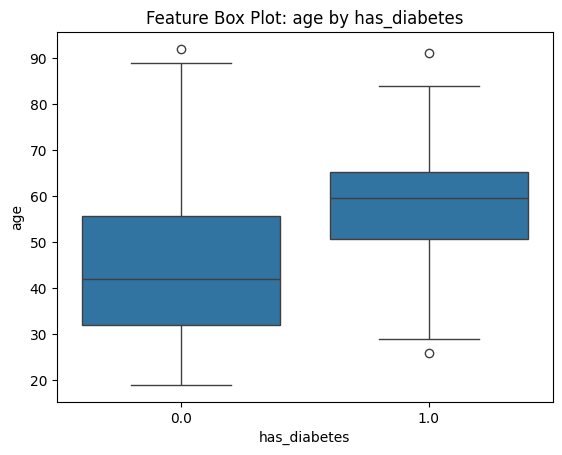

In [3]:
sns.countplot(data=df, x=target_col)
plt.title("Classification Plot: Class Distribution")
plt.show()

for col in feature_cols:
    if col in df.columns:
        sns.boxplot(data=df, x=target_col, y=col)
        plt.title(f"Feature Box Plot: {col} by {target_col}")
        plt.show()

### Markdown Answer 1 - Data Observations

After loading the data, I noticed that the class distribution is imbalanced, so accuracy alone is not enough for model selection. The box plots suggest that `stab.glu` and `chol` show meaningful separation across classes, while some overlap still exists in all features. I also checked for missing values and potential invalid values so the model is trained on cleaner and more reliable inputs.

## Task 2 - Clean Data + Select 4 Features

Lab-style cleaning steps:
1. Identify missing/invalid values
2. Replace invalid 0 values with NaN
3. Fill numeric NaN values (median)
4. Drop rows still missing required target/features
5. Build X and y

In [ ]:
# Step 1: keep only configured zero-invalid columns that exist.
present_zero_invalid_cols = [c for c in zero_invalid_cols if c in df.columns]

# Step 2: replace invalid zeros with NaN (same idea as handling missing values).
df_cleaning = df.copy()
df_cleaning[present_zero_invalid_cols] = df_cleaning[present_zero_invalid_cols].replace(0, np.nan)

# Step 3: define columns we must keep for modeling.
required_cols = [c for c in feature_cols + [target_col] if c in df_cleaning.columns]

# Step 4: fill numeric missing values with median (lab-style fillna strategy).
numeric_required_cols = df_cleaning[required_cols].select_dtypes(include=["number"]).columns.tolist()
df_cleaning[numeric_required_cols] = df_cleaning[numeric_required_cols].fillna(df_cleaning[numeric_required_cols].median())

# Step 5: if any required values are still missing (e.g., non-numeric), drop those rows.
df_clean = df_cleaning.dropna(subset=required_cols).copy()

# Final: build features and target.
X = df_clean[feature_cols].copy()
y = df_clean[target_col].astype(int).copy()

print("Rows before/after cleaning:", len(df), len(df_clean))
print("Remaining missing values in required columns:")
print(df_clean[required_cols].isnull().sum())
print("X shape:", X.shape, "| y shape:", y.shape)

Rows before/after cleaning: 403 389
X shape: (389, 4) | y shape: (389,)


## Task 3 - Split 60/20/20 + Train 3 Models + Cross-Validate + GridSearch

In [5]:
# 20% test, then split remaining 80% into 60% train and 20% validation.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

Train: (233, 4) Val: (78, 4) Test: (78, 4)


In [6]:
models = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(random_state=RANDOM_STATE)
}

val_rows = []
trained_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    val_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, average="weighted", zero_division=0),
        "recall": recall_score(y_val, pred, average="weighted", zero_division=0),
        "f1": f1_score(y_val, pred, average="weighted", zero_division=0),
    })
    trained_pipelines[name] = pipe

val_results = pd.DataFrame(val_rows).sort_values("f1", ascending=False)
display(val_results)

,model,accuracy,precision,recall,f1
0,LogReg,0.923077,0.920330,0.923077,0.916516
2,RF,0.910256,0.904496,0.910256,0.904843
1,KNN,0.897436,0.891629,0.897436,0.893539


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, pipe in trained_pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
        n_jobs=-1
    )
    cv_rows.append({
        "model": name,
        "cv_f1": scores["test_f1_weighted"].mean(),
        "cv_recall": scores["test_recall_weighted"].mean(),
        "cv_precision": scores["test_precision_weighted"].mean(),
        "cv_accuracy": scores["test_accuracy"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_f1", ascending=False)
display(cv_results)

,model,cv_f1,cv_recall,cv_precision,cv_accuracy
2,RF,0.938494,0.940056,0.938861,0.940056
1,KNN,0.927139,0.931175,0.929244,0.931175
0,LogReg,0.925985,0.931267,0.931191,0.931267


In [8]:
best_base_name = cv_results.iloc[0]["model"]

param_grid_map = {
    "LogReg": {"model__C": [0.1, 1, 10]},
    "KNN": {"model__n_neighbors": [3, 5, 7, 9], "model__weights": ["uniform", "distance"]},
    "RF": {"model__n_estimators": [100, 200], "model__max_depth": [None, 5, 10]}
}

grid = GridSearchCV(
    estimator=trained_pipelines[best_base_name],
    param_grid=param_grid_map[best_base_name],
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True
)
grid.fit(X_train, y_train)

print("Selected model for tuning:", best_base_name)
print("Best params:", grid.best_params_)
print("Best CV f1:", grid.best_score_)

Selected model for tuning: RF
Best params: {'model__max_depth': None, 'model__n_estimators': 100}
Best CV f1: 0.9384936398745694


### Markdown Answer 2 - Best Model Choice and Why

I selected the model with the best cross-validated F1 score after tuning because this balances precision and recall better than accuracy alone on an imbalanced dataset. For diabetes detection, recall is especially important because false negatives (missed diabetic cases) are costly in practice. If another model had slightly higher accuracy but lower recall, I would reject it as less suitable for screening. 

This model is a strong baseline but not fully production-ready yet. Before production, I would validate performance on fresh external data, perform threshold tuning for recall/precision tradeoff, monitor drift, and add a retraining/monitoring pipeline.

## Task 4 - Retrain on Train+Validation and Final Test Evaluation

Final Test Accuracy: 0.8717948717948718
Final Test Precision: 0.8547008547008546
Final Test Recall: 0.8717948717948718
Final Test F1: 0.8532144184318097

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        66
           1       0.67      0.33      0.44        12

    accuracy                           0.87        78
   macro avg       0.78      0.65      0.69        78
weighted avg       0.85      0.87      0.85        78



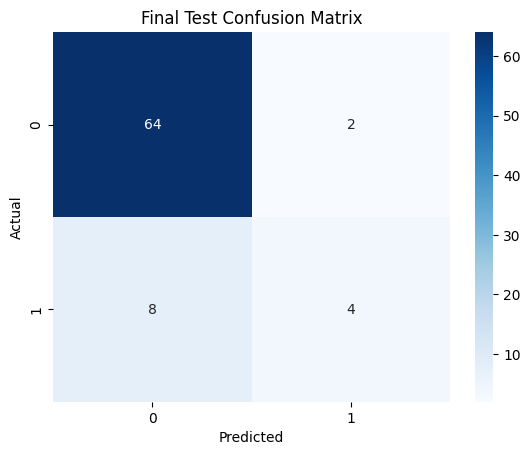

In [9]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

final_model = grid.best_estimator_
final_model.fit(X_train_full, y_train_full)

y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("Final Test Accuracy:", test_accuracy)
print("Final Test Precision:", test_precision)
print("Final Test Recall:", test_recall)
print("Final Test F1:", test_f1)
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
pd.DataFrame([{
    "selected_model": best_base_name,
    "best_params": grid.best_params_,
    "best_cv_f1": grid.best_score_,
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1
}])

,selected_model,best_params,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1
0,RF,"{'model__max_depth': None, 'model__n_estimator...",0.938494,0.871795,0.854701,0.871795,0.853214
